K = 3 n = 336 n/K = 112.0 n/(32*K^2) = 1.0
336


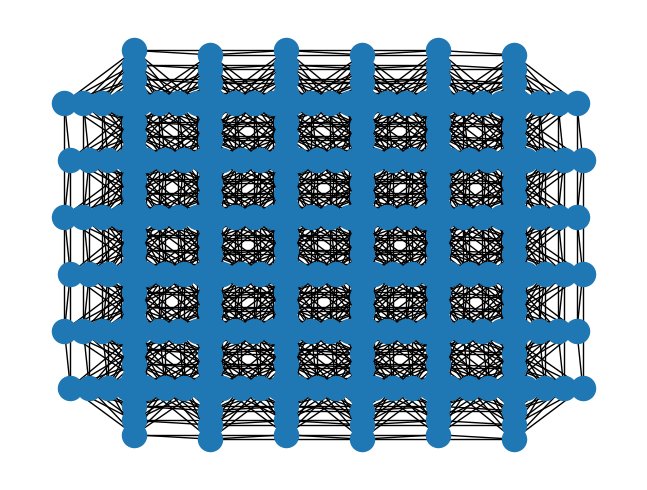

In [89]:
'''
This file is a first attempt to create some custom BMs 
based on the D-Wave Zephyr Graph architecture. 

As of 08/12/2025: 
What has been done: 
Mainly: 
- Generate Zephyr graph
- Assign visible & hidden nodes in the graph 
- Train the resulting BM

Also: 
- Removal of some poorly connected nodes in the graph
- Visualizations: Visible vs Hidden in Zephyr graph 

All this is using the previous functionalities from 
custom_bm.py, which implements the custom architecture 
BMs and handles the PCD, sampling, etc 
--> Improvements there make improvements here! 


To do: 
- Need a meaningful assignment of visible nodes to 
pixels in the image. Right now, it's just the order of labels in 
the graph nodes with order of pixel labels. 
    Probably: Group closeby pixels together somehow
- Speed things up (in custom_BMs, probably)
    --> GPU? 
    --> Faster Gibbs sampling (e.g. with Julia?)
    --> Partition the graph for block Gibbs sampling? 
        - Maybe just need to partition Zephyr graph once...
- Hyperparameter tuning (issue: it's slow to run)
    - Right now no images are looking good at all! 
    - Tune things to get good values. 


'''

'''
8/17/25

Tried assigning pixels to nodes in a way that preserves locality.
Instead of first 144 visible, I tried to group nearby pixels together using degrees of each node.

Also, trained using more gibbs step in training (5 -> 10), more epochs (20 -> 50 -> 100), 
'''

'''
8/24/25

Experimented with different assignments for visible. Specifically:
-> assigning second half as visible, and then using the 12x12 grid 
->  removing node relabling after node removal resulted
-> (*the first time I removed node relabling, and assigned second half as visible (no other changes), there was
        weirdly massive improvement in training (PCD ~0), and the samples looked better as well.
         Have been trying to figure out why it happened for just that run, and replicate it for now but no luck :(

8/30/25

Pre-emptive tuning (esp. lower learning rate) to get a decreasing avg PCD loss, which was a success but the quality of samples degraded.
I believe it was an overfitting issue then. 
'''
import dwave_networkx as dnx
import numpy as np
import networkx as nx

# Heler functions
# Get 2D positions for Zephyr nodes (Zephyr layout)
def get_zephyr_positions(G):
    try:
        # If available, this reflects physical qubit layout
        pos = dnx.zephyr_layout(G)  # dict: node -> (x, y)
    except Exception:
        # fallback: deterministic spring layout
        pos = nx.spring_layout(G, seed=42, dim=2)
    return pos

#  Assigning 144 visibles by laying a 12x12 grid over the layout and
#  greedily taking the nearest unique node to each grid cell center.
def assign_visibles_by_grid(G, grid_shape=(12*12), min_degree=3):
    pos = get_zephyr_positions(G)
    nodes = np.array(sorted(G.nodes()))
    coords = np.array([pos[n] for n in nodes])  # shape (N, 2)
    if coords.size == 0:
        print("Warning: No eligible nodes found, relaxing min_degree constraint.")
        nodes = list(G.nodes())  # fallback: use all nodes
        coords = np.array([pos[n] for n in nodes])

    # grid centers across the layout bounding box
    xs, ys = coords[:, 0], coords[:, 1]
    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = ys.min(), ys.max()

    nrows, ncols = grid_shape
    grid_x = np.linspace(xmin, xmax, ncols)
    # flip y so row 0 is top
    grid_y = np.linspace(ymax, ymin, nrows)

    selected = []
    used = set()

    # function to pick nearest unused node to target (x,y), optionally with min degree
    def pick_nearest(target_xy):
        # candidates not used yet
        mask = [n for n in nodes if n not in used]
        if not mask:
            raise RuntimeError("Ran out of nodes to assign as visibles")
        pts = np.array([pos[n] for n in mask])
        d2 = np.sum((pts - target_xy) ** 2, axis=1)
        order = np.argsort(d2)
        if min_degree is None:
            return mask[order[0]]
        # prefer nodes with degree >= min_degree, otherwise next nearest
        for idx in order:
            if G.degree[mask[idx]] >= min_degree:
                return mask[idx]
        return mask[order[0]]  # fallback

    # row-major over the image grid -> preserves pixel locality
    for r in range(nrows):
        for c in range(ncols):
            chosen = pick_nearest(np.array([grid_x[c], grid_y[r]]))
            selected.append(chosen)
            used.add(chosen)

    return selected  # list of node ids in pixel (row-major) order

#   Relabel graph so selected visibles become 0..(v-1) in pixel order.
#    All remaining nodes (hidden) become v..(v+h-1).
def relabel_visible_first(G, visible_nodes_in_pixel_order):
    visible_set = set(visible_nodes_in_pixel_order)
    hidden_nodes = [n for n in sorted(G.nodes()) if n not in visible_set]

    mapping = {}
    # visibles first in the order that matches pixel order
    for new_i, old in enumerate(visible_nodes_in_pixel_order):
        mapping[old] = new_i
    # hiddens after
    offset = len(visible_nodes_in_pixel_order)
    for j, old in enumerate(hidden_nodes):
        mapping[old] = offset + j

    G2 = nx.relabel_nodes(G, mapping, copy=True)
    return G2, mapping

def draw_zephyr_hidden_visible(G, vh_nodearray):
    '''
    Draws G as a zephyr graph topology, with visible / hidden nodes as labeled in vh_nodearray
    G: Networkx Graph
    vh_nodearray: numpy array of 0 and 1s -- 1 for visible, 0 for hidden

    hidden nodes will be blue, and visibles red. 
    '''
    vh_dict = {} #dnx.draw needs dict 

    #assigning large negative or positive value for v vs h
    for i, entry in enumerate(vh_nodearray):
        vh_dict[i] = (entry-0.5)*1000

    #using linear biases, which dnx can color code, 
    # to do the actual coloring 
    dnx.draw_zephyr(G, linear_biases=vh_dict)
    return None

K = 3
G = dnx.zephyr_graph(K)
n = G.number_of_nodes()
print('K =', K, 'n =', n, 'n/K =', n/K, 
      'n/(32*K^2) =', n/(32*K**2+16*K))

dnx.draw_zephyr(G)
print(G.number_of_nodes())

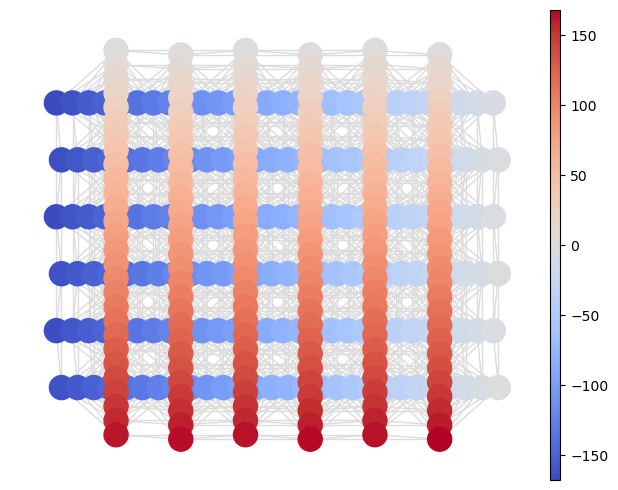

In [90]:
#visualize labelling
#label all the nodes in the graph as visible 1 or hidden 0 
n = G.number_of_nodes()
lin_biases = {i: (i-n/2) for i in range(n)}

dnx.draw_zephyr(G, linear_biases=lin_biases)

Number of nodes: 336
Number of visibles: 168.0
Number of hiddens: 168.0


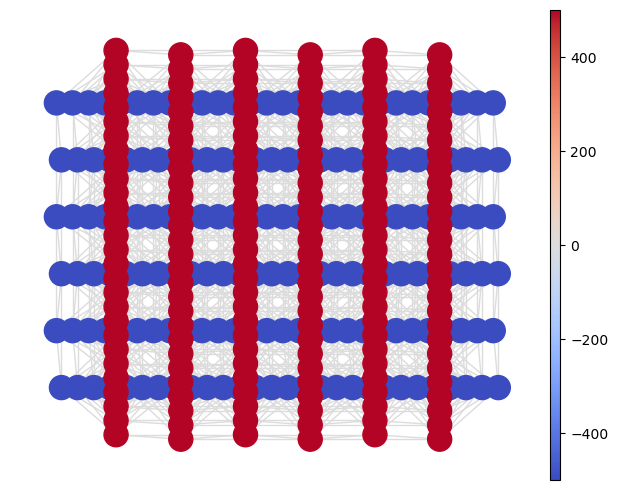

In [91]:
#label all the nodes in the graph as visible 1 or hidden 0 
n = G.number_of_nodes()
vh_nodearray = np.zeros(n) 


vh_nodearray[int(np.floor(n/2)):] = 1  # second half as visible
node_labels = {i: 'visible' if label == 1 else 'hidden' for i, label in enumerate(vh_nodearray)}


num_visible = sum(vh_nodearray)
num_hidden = n-num_visible
print('Number of nodes:', n)
print('Number of visibles:', num_visible)
print('Number of hiddens:', num_hidden)

draw_zephyr_hidden_visible(G, vh_nodearray)

# Remove nodes from G (may need to change how this is done)
#Note this is temporary to work around having too many nodes for this dataset

final_num_vis = 144 #this is the target number of vis nodes
vis_to_remove = num_visible - final_num_vis
# Remove nodes alternately from the start and end of the node list

Updated number of visibles: 144
Updated number of hiddens: 144
Graph has 288 nodes and 2368 edges
V-V edges: 562, H-H edges: 698, V-H edges: 1108


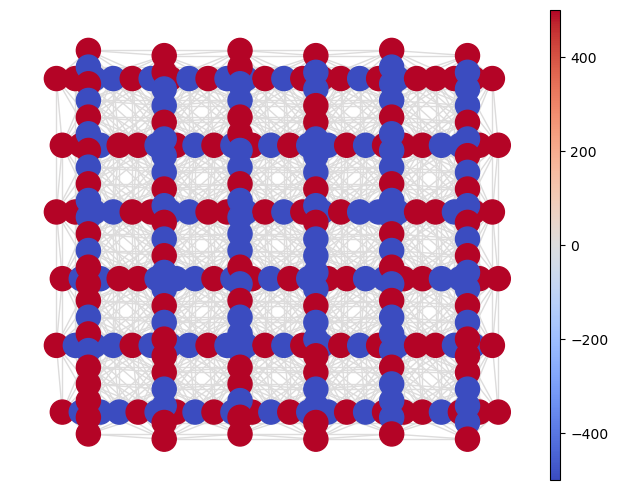

In [92]:
nodes_sorted = np.array(sorted(G.nodes()), dtype=int)

'''
Next is a very specific way of removing some nodes. 
Namely, these nodes (0 to 4K, n/2-4K to n/2+4K, and n-4K to n) 
are poorly connected (they are on the "edge" of the chip / graph)

'''
nodes_to_remove = np.array([], dtype = 'int')
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(0, 4*K)))
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(round(n/2)-4*K, round(n/2)+4*K)))
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(n-4*K, n)))



G.remove_nodes_from(nodes_to_remove)

# Relabel nodes to go from 0 to (new number of nodes - 1)
G = nx.convert_node_labels_to_integers(G, ordering='sorted')


# Pick 144 visible nodes that preserve locality (12x12)
num_visible = 144
visible_nodes_in_pixel_order = assign_visibles_by_grid(G, grid_shape=(12, 12), min_degree=3)  # min_degree optional
assert len(visible_nodes_in_pixel_order) == num_visible

# Relabel so visibles are 0..143 in pixel (row-major) order and then hiddens after that
G, mapping_old_to_new = relabel_visible_first(G, visible_nodes_in_pixel_order) # ewmoving this resulted in massive improvement in training

# Build vh_nodearray and node_labels consistent with your downstream code
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int)
vh_nodearray[:num_visible] = 1  # visibles are indices 0..143 now
node_labels = {i: 'visible' if i < num_visible else 'hidden' for i in range(n)}

# print stats
num_hidden = n - num_visible
print('Updated number of visibles:', num_visible)
print('Updated number of hiddens:', num_hidden)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < num_visible and v < num_visible)
hh_edges = sum(1 for u, v in G.edges() if u >= num_visible and v >= num_visible)
vh_edges = sum(1 for u, v in G.edges() if (u < num_visible) != (v < num_visible))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

draw_zephyr_hidden_visible(G, vh_nodearray)             # DWN’s Zephyr look

Loading dataset...
Found existing .\mnist12x12_trainfeats.npy and .\mnist12x12_trainlabels.npy.
Found existing .\mnist12x12_testfeats.npy and .\mnist12x12_testlabels.npy.


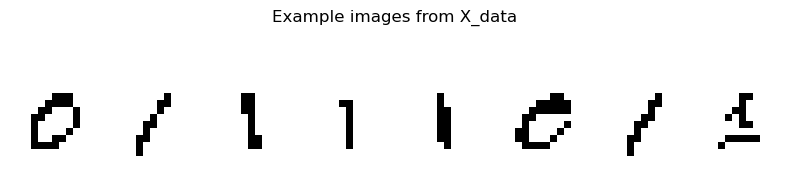

In [93]:
from custom_BMs import *

# --- Dataset Loading ---
from skimage.transform import resize
import pandas as pd
import os

def generate_downsized_mnist(output_dir=".", grid_shape=(12, 12), cutoff=0.5):
    """
    Generates downsized MNIST .npy files if not already present.
    """
    input_files = {
        "train": "mnist_train.csv",
        "test": "mnist_test.csv"
    }

    os.makedirs(output_dir, exist_ok=True)

    def process_csv(filename, cutoff):
        df = pd.read_csv(filename)
        labels = df.iloc[:, 0].values
        images = df.iloc[:, 1:].values.astype(np.float32) / 255.0  # scale to [0,1]
        downsized = []
        for img in images:
            img_2d = img.reshape(28, 28)
            img_small = resize(img_2d, grid_shape, order=1, anti_aliasing=True, preserve_range=True)
            img_bin = (img_small >= cutoff).astype(np.uint8)
            downsized.append(img_bin)
        return np.array(downsized), labels

    for split in ["train", "test"]:
        out_feats = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}feats.npy")
        out_labels = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}labels.npy")
        if not (os.path.exists(out_feats) and os.path.exists(out_labels)):
            print(f"Generating {out_feats} and {out_labels}...")
            feats, labels = process_csv(input_files[split], cutoff)
            np.save(out_feats, feats)
            np.save(out_labels, labels)
        else:
            print(f"Found existing {out_feats} and {out_labels}.")

    return (
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainfeats.npy")),
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainlabels.npy"))
    )

# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = generate_downsized_mnist(output_dir=".", grid_shape=(12, 12))
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, 144) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
num_images_to_use = 200
mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())
# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() < 0.5 + roundup_boost).float()
dataset = torch.utils.data.TensorDataset(X_data)

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(12, 12), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

Graph has 288 nodes and 2368 edges
V-V edges: 562, H-H edges: 698, V-H edges: 1108


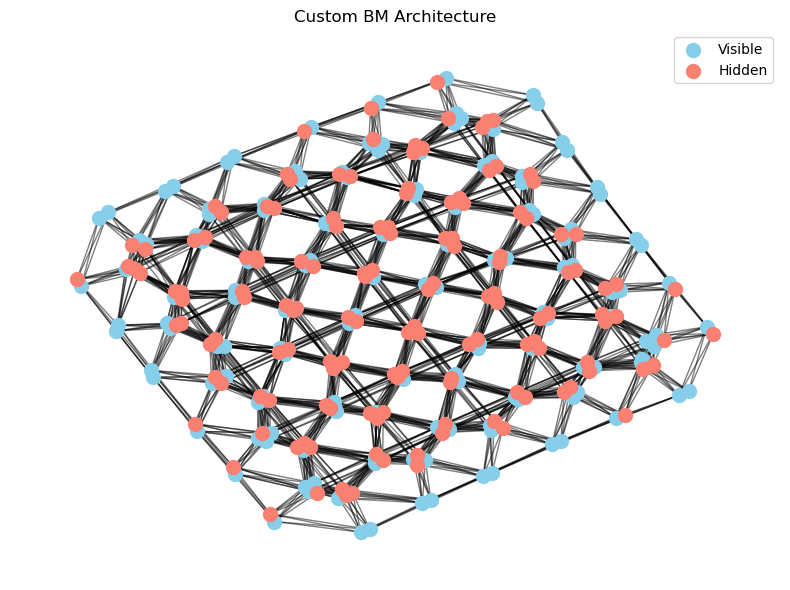

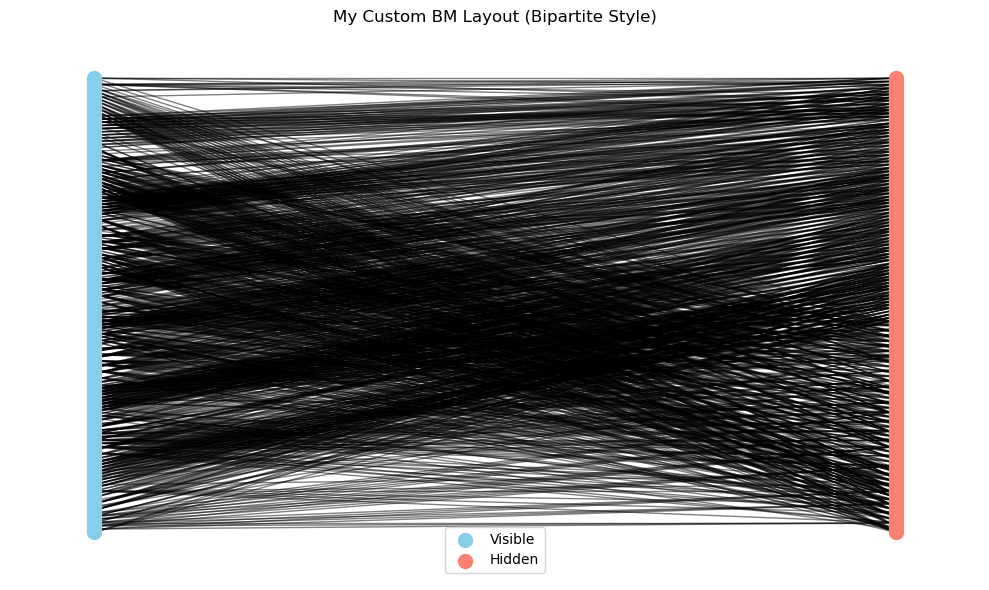

Building Boltzmann Machine from graph... 🏗️
Starting PCD training on cpu for 38 epochs... 🏋️
Epoch 1/38 | Avg PCD Loss: -2.0003
Epoch 2/38 | Avg PCD Loss: -5.3681
Epoch 3/38 | Avg PCD Loss: -7.4976
Epoch 4/38 | Avg PCD Loss: -9.0020
Epoch 5/38 | Avg PCD Loss: -10.5989
Epoch 6/38 | Avg PCD Loss: -11.7166
Epoch 7/38 | Avg PCD Loss: -12.9605
Epoch 8/38 | Avg PCD Loss: -14.1929
Epoch 9/38 | Avg PCD Loss: -15.1035
Epoch 10/38 | Avg PCD Loss: -15.8684
Epoch 11/38 | Avg PCD Loss: -17.0635
Epoch 12/38 | Avg PCD Loss: -17.9137
Epoch 13/38 | Avg PCD Loss: -18.3698
Epoch 14/38 | Avg PCD Loss: -19.4599
Epoch 15/38 | Avg PCD Loss: -20.0006
Epoch 16/38 | Avg PCD Loss: -20.3352
Epoch 17/38 | Avg PCD Loss: -21.1512
Epoch 18/38 | Avg PCD Loss: -21.6418
Epoch 19/38 | Avg PCD Loss: -22.8434
Epoch 20/38 | Avg PCD Loss: -23.3051
Epoch 21/38 | Avg PCD Loss: -22.9685
Epoch 22/38 | Avg PCD Loss: -24.1211
Epoch 23/38 | Avg PCD Loss: -24.3793
Epoch 24/38 | Avg PCD Loss: -24.4419
Epoch 25/38 | Avg PCD Loss: -24.

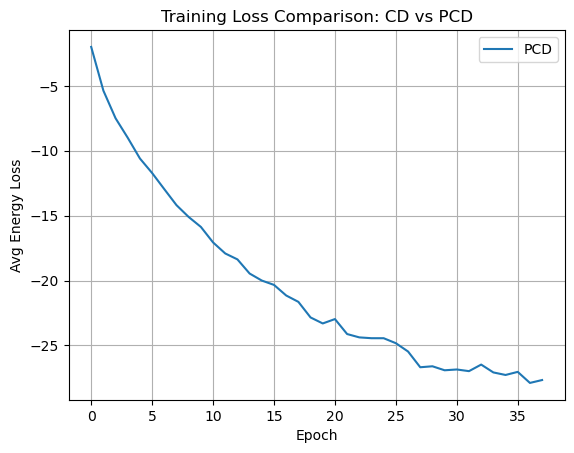

In [94]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.0003  # You can change this value for experiments 
l2_amount = 0.0001  # L2 regularization amount
num_epochs = 38
batch_size = 50  
num_gibbs_steps = 20 #number of gibbs loops to do in training
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



# Print some graph statistics
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < num_visible and v < num_visible)
hh_edges = sum(1 for u, v in G.edges() if u >= num_visible and v >= num_visible)
vh_edges = sum(1 for u, v in G.edges() if (u < num_visible) != (v < num_visible))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

visualize_bm_graph(G, node_labels, title="Custom BM Architecture")
visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = graph_to_bm(G, node_labels)

# --- Training ---
optimizer_pcd = torch.optim.RMSprop(model_pcd.parameters(), lr=step_size, weight_decay=l2_amount)
pcd_losses = train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, batch_size=batch_size, step_size=step_size)

# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()


--- Generating samples using Gibbs Sampling ---
Running Gibbs sampler for 8 samples, 100 burn-in steps each... 🔥
  Gibbs sample 1/8
  Gibbs sample 2/8
  Gibbs sample 3/8
  Gibbs sample 4/8
  Gibbs sample 5/8
  Gibbs sample 6/8
  Gibbs sample 7/8
  Gibbs sample 8/8
Gibbs sampling complete.

Displaying generated images... 🖼️


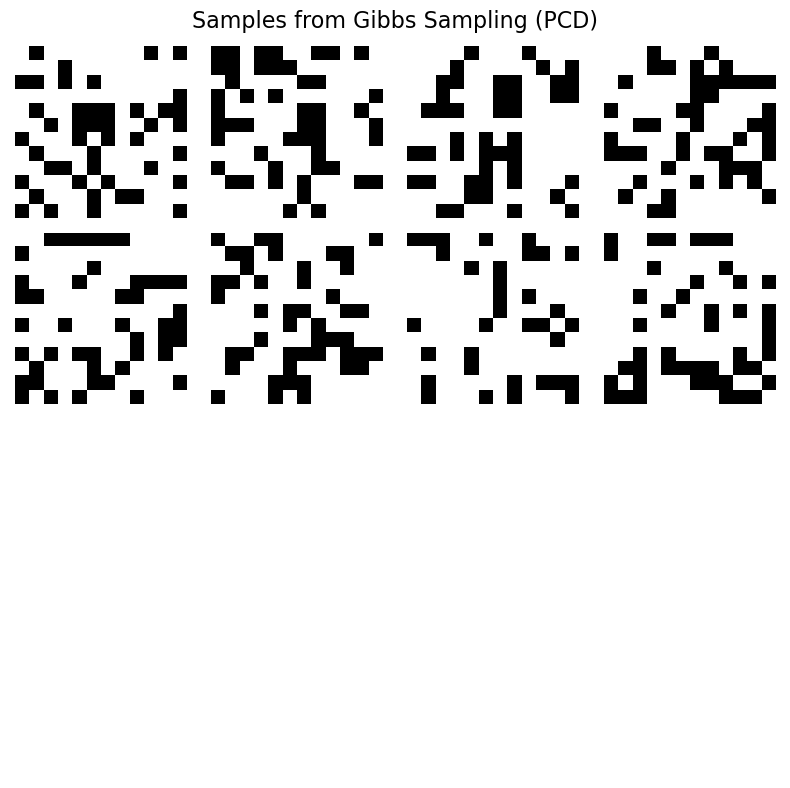

In [95]:
#--- Sampling & Visualization ---
num_gen_samples = 8
burn_in = 100


#need to find a way to speed up these sampling functions, so slow
print("\n--- Generating samples using Gibbs Sampling ---")
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(12, 12), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples from Gibbs Sampling (PCD)")


--- Improving samples with Tabu Search ---

Displaying Tabu Search improved images... 🖼️


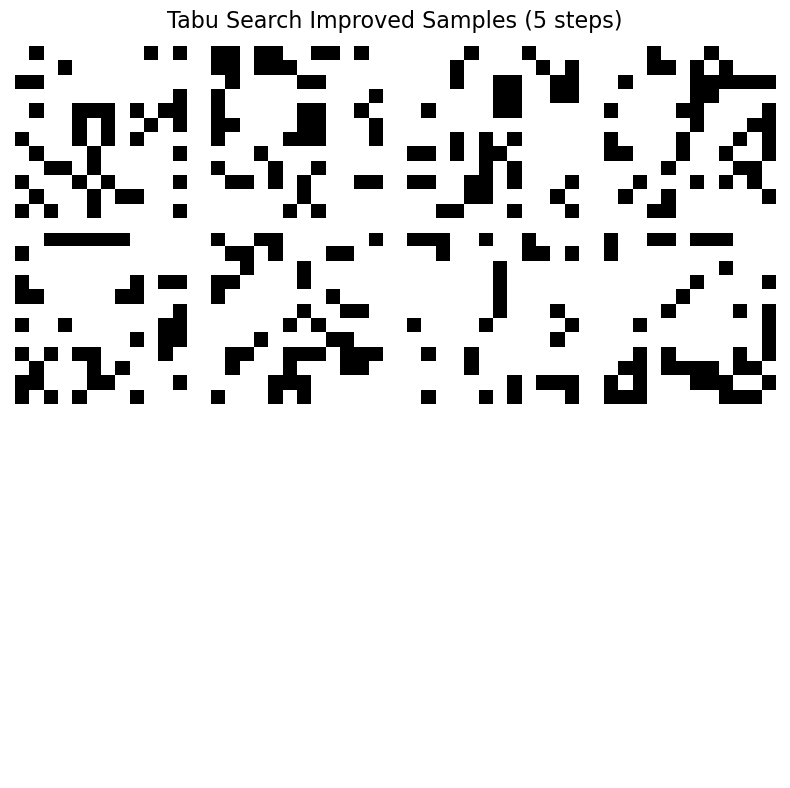

In [96]:
print("\n--- Improving samples with Tabu Search ---")
tabu_steps = 5
tabu_improved_samples = []
for i in range(samples_pcd.shape[0]):
    v_init = samples_pcd[i].unsqueeze(0)
    improved_v = tabu_search_bm(model_pcd, v_init, steps=tabu_steps)
    tabu_improved_samples.append(improved_v)
tabu_improved_samples = torch.stack(tabu_improved_samples, dim=0)

print("\nDisplaying Tabu Search improved images... 🖼️")
plot_samples(tabu_improved_samples, f"Tabu Search Improved Samples ({tabu_steps} steps)")